In [34]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [35]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

models_reg = {
    'LogReg': Ridge(),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'CatBoost': CatBoostRegressor(iterations=100, random_seed=42, verbose=0),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'MLP': MLPRegressor(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'Dummy': DummyRegressor()
}

In [36]:
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                             accuracy_score, balanced_accuracy_score, 
                             f1_score, r2_score, mean_absolute_error)
from sklearn.model_selection import StratifiedKFold, KFold

def evaluate_models(X, y, models, task_type='binary', n_splits=5, random_state=42):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state) if task_type == 'regression' else StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = {}
    for name, clf in models.items():
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('clf', clf)
        ])
        metrics = {m: [] for m in (['AUROC', 'AUPRC', 'Accuracy', 'BalancedAcc', 'F1'] if task_type == 'binary'
                                    else ['AUROC', 'Accuracy', 'BalancedAcc', 'F1'] if task_type == 'multiclass'
                                    else ['R2', 'MAE'])}
        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            pipe.fit(X_train, y_train)
            if task_type == 'binary':
                y_prob = pipe.predict_proba(X_test)[:, 1]
                y_pred = pipe.predict(X_test)
                metrics['AUROC'].append(roc_auc_score(y_test, y_prob))
                metrics['AUPRC'].append(average_precision_score(y_test, y_prob))
                metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
                metrics['BalancedAcc'].append(balanced_accuracy_score(y_test, y_pred))
                metrics['F1'].append(f1_score(y_test, y_pred))
            elif task_type == 'multiclass':
                y_prob = pipe.predict_proba(X_test)
                y_pred = pipe.predict(X_test)
                metrics['AUROC'].append(roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'))
                metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
                metrics['BalancedAcc'].append(balanced_accuracy_score(y_test, y_pred))
                metrics['F1'].append(f1_score(y_test, y_pred, average='macro'))
            else:
                y_pred = pipe.predict(X_test)
                metrics['R2'].append(r2_score(y_test, y_pred))
                metrics['MAE'].append(mean_absolute_error(y_test, y_pred))
        results[name] = {m: f"{np.mean(v):.3f} ± {np.std(v):.3f}" for m, v in metrics.items()}
    return results

In [37]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    'CatBoost': CatBoostClassifier(iterations=100, random_seed=42, verbose=0, auto_class_weights='Balanced'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', verbose=-1),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Dummy': DummyClassifier(strategy='most_frequent'),
}

In [38]:
task_dir = '/Users/alva/Documents/nhanes_tasks/data/tasks/'
all_results = {}
task_types = {}
for fname in sorted(os.listdir(task_dir)):
    if not fname.endswith('.pkl'):
        continue
    with open(os.path.join(task_dir, fname), 'rb') as f:
        task = pickle.load(f)
    name = task['name']
    task_type = task.get('type', 'binary')
    X, y = task['X'], task['y']
    print(f"\n=== {name} (n={len(y)}, type={task_type}) ===")
    task_types[name] = task_type
    if task_type == 'binary':
        scale = (y==0).sum() / (y==1).sum()
        models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42,
                                           scale_pos_weight=scale, verbosity=0)
    current_models = models_reg if task_type == 'regression' else models
    results = evaluate_models(X, y, current_models, task_type=task_type)
    all_results[name] = results
    for m, v in results.items():
        print(f"  {m}: {v}")


task_meta = {}
for fname in sorted(os.listdir(task_dir)):
    if not fname.endswith('.pkl'):
        continue
    with open(os.path.join(task_dir, fname), 'rb') as f:
        task = pickle.load(f)
    name = task['name']
    task_type = task.get('type', 'binary')
    y = task['y']
    n = len(y)
    if task_type == 'binary':
        prevalence = round(y.mean(), 3)
    elif task_type == 'multiclass':
        prevalence = None
    else:
        prevalence = None
    dataset = 'ADNI' if 'adni' in name or 'tadpole' in name else 'NHANES'
    task_meta[name] = {
        'Dataset': dataset,
        'Type': task_type,
        'n': n,
        'Prevalence': prevalence
    }

overview = pd.DataFrame(task_meta).T.reset_index().rename(columns={'index': 'Task'})
overview = overview.sort_values(['Dataset', 'Type'])
print(overview.to_string(index=False))


=== adni_conv (n=623, type=binary) ===
  LogReg: {'AUROC': '0.856 ± 0.044', 'AUPRC': '0.793 ± 0.058', 'Accuracy': '0.761 ± 0.026', 'BalancedAcc': '0.760 ± 0.031', 'F1': '0.705 ± 0.039'}
  XGBoost: {'AUROC': '0.848 ± 0.029', 'AUPRC': '0.776 ± 0.028', 'Accuracy': '0.769 ± 0.028', 'BalancedAcc': '0.753 ± 0.034', 'F1': '0.691 ± 0.046'}
  CatBoost: {'AUROC': '0.871 ± 0.030', 'AUPRC': '0.803 ± 0.038', 'Accuracy': '0.806 ± 0.028', 'BalancedAcc': '0.801 ± 0.036', 'F1': '0.751 ± 0.043'}
  MLP: {'AUROC': '0.816 ± 0.016', 'AUPRC': '0.739 ± 0.028', 'Accuracy': '0.766 ± 0.017', 'BalancedAcc': '0.742 ± 0.011', 'F1': '0.675 ± 0.015'}
  RandomForest: {'AUROC': '0.869 ± 0.029', 'AUPRC': '0.787 ± 0.043', 'Accuracy': '0.807 ± 0.021', 'BalancedAcc': '0.782 ± 0.029', 'F1': '0.725 ± 0.040'}
  LightGBM: {'AUROC': '0.853 ± 0.039', 'AUPRC': '0.757 ± 0.053', 'Accuracy': '0.777 ± 0.043', 'BalancedAcc': '0.764 ± 0.052', 'F1': '0.704 ± 0.068'}
  ExtraTrees: {'AUROC': '0.861 ± 0.032', 'AUPRC': '0.776 ± 0.048', 'Ac

In [39]:
def normalized_score(results_df):
    scores = results_df.copy()
    for col in scores.columns:
        scores[col] = scores[col].str.split(' ±').str[0].astype(float)
    normalized = scores.copy()
    for idx in scores.index:
        row = scores.loc[idx]
        best, worst = row.max(), row.min()
        if best == worst:
            normalized.loc[idx] = 1.0
        else:
            normalized.loc[idx] = (row - worst) / (best - worst)
    return normalized

df = pd.DataFrame(all_results).T

primary_metric = {
    'binary': 'AUROC',
    'multiclass': 'AUROC',
    'regression': 'R2'
}


primary_results = {}
for task_name, model_results in all_results.items():
    task_type = task_types[task_name]  # se nedan
    metric = primary_metric[task_type]
    primary_results[task_name] = {m: v[metric] for m, v in model_results.items()}

df = pd.DataFrame(primary_results).T

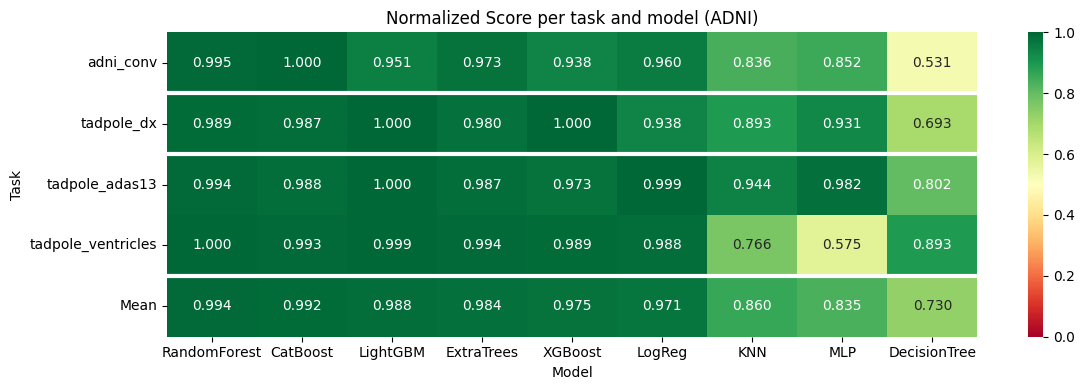

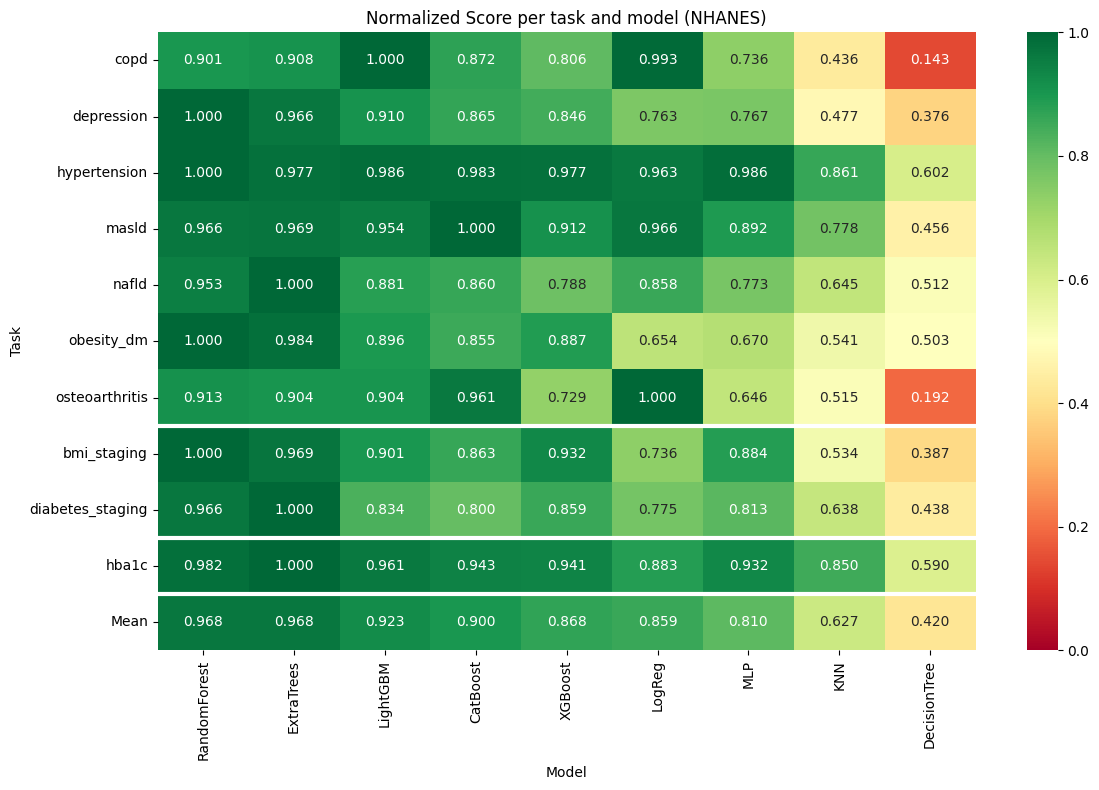

 Rank        Model  Mean Normalized Score
    1 RandomForest               0.975582
    2   ExtraTrees               0.972284
    3     LightGBM               0.941269
    4     CatBoost               0.926441
    5      XGBoost               0.898301
    6       LogReg               0.891011
    7          MLP               0.817020
    8          KNN               0.693821
    9 DecisionTree               0.508373


In [ ]:
norm_df = normalized_score(df)
plot_df = norm_df.drop(columns=['Dummy'], errors='ignore')


task_order = (
    pd.Series(task_types)
    .reset_index()
    .rename(columns={'index': 'task', 0: 'type'})
    .assign(dataset=lambda x: x['task'].apply(lambda t: 'ADNI' if 'adni' in t or 'tadpole' in t else 'NHANES'))
    .sort_values(['dataset', 'type'])
)


for dataset in ['ADNI', 'NHANES']:
    tasks = task_order[task_order['dataset'] == dataset]['task'].tolist()
    sub_df = plot_df.loc[tasks].copy()
    
    col_order = sub_df.mean(axis=0).sort_values(ascending=False).index
    sub_df = sub_df[col_order]
    

    mean_row = sub_df.mean(axis=0).rename('Mean')
    sub_df = pd.concat([sub_df, mean_row.to_frame().T])
    
    types = task_order[task_order['dataset'] == dataset].set_index('task')['type']
    separators = []
    prev = None
    for i, t in enumerate(tasks):
        if prev and types[t] != prev:
            separators.append(i)
        prev = types[t]
    
    fig, ax = plt.subplots(figsize=(12, max(4, len(tasks) * 0.8)))
    sns.heatmap(sub_df.round(3), annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
    ax.set_title(f'Normalized Score per task and model ({dataset})')
    ax.set_xlabel('Model')
    ax.set_ylabel('Task')
    for sep in separators:
        ax.axhline(y=sep, color='white', linewidth=3)
    ax.axhline(y=len(sub_df) - 1, color='white', linewidth=3)
    plt.tight_layout()
    plt.show()

overall_rank = norm_df.drop(columns=['Dummy'], errors='ignore').mean(axis=0).sort_values(ascending=False).reset_index()
overall_rank.columns = ['Model', 'Mean Normalized Score']
overall_rank['Rank'] = range(1, len(overall_rank) + 1)
print(overall_rank[['Rank', 'Model', 'Mean Normalized Score']].to_string(index=False))